In [ ]:
!pip install osmnx geopandas shapely pyproj --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.5/100.5 kB 3.0 MB/s eta 0:00:00


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((503197.317 5032658.859, 503200.815 5...",9.040887,45.386738,9.27811,45.535848,397707315,relation,44915,45.464194,9.189635,boundary,administrative,16,0.789949,city,Milan,"Milan, Lombardy, Italy"


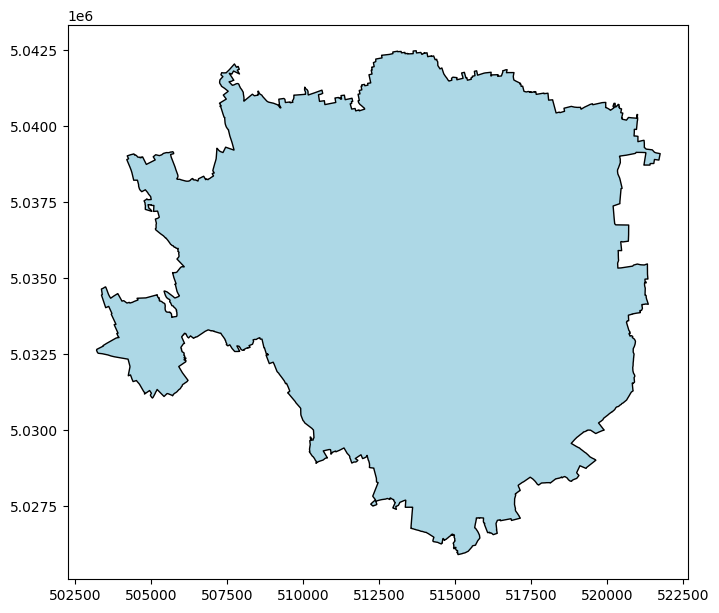

In [ ]:
import osmnx as ox
import geopandas as gpd

# Download and reproject Milan's administrative boundary
milano = ox.geocode_to_gdf("Comune di Milano, Italia").to_crs(epsg=32632)

milano.plot(edgecolor='black', facecolor='lightblue', figsize=(8, 8))
milano.to_file("milano_boundary.geojson", driver="GeoJSON")

milano


Downloading...
From: https://drive.google.com/uc?id=1QZLg2b9OGUsi6rv4kFZlGgFxCut3nCGz
To: /content/ds964_nil_wm.geojson
100%|██████████| 1.02M/1.02M [00:00<00:00, 34.5MB/s]


,ID_NIL,NIL,Valido_dal,Valido_al,Fonte,Shape_Length,Shape_Area,OBJECTID,geometry
0,48,RONCHETTO SUL NAVIGLIO - Q.RE LODOVICO IL MORO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,8723.368714,2.406306e+06,89,"POLYGON ((512062.065 5031592.5, 511946.351 503..."
1,64,TRENNO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,3309.998800,4.896921e+05,90,"POLYGON ((508300.627 5037409.029, 508275.722 5..."
2,67,PORTELLO,05/02/2020,Vigente,Milano 2030 - PGT Approvato,3800.750663,9.096022e+05,91,"POLYGON ((512218.673 5037159.04, 512108.13 503..."
3,81,BOVISASCA,05/02/2020,Vigente,Milano 2030 - PGT Approvato,7105.469715,1.578028e+06,92,"POLYGON ((513122.815 5040992.086, 513091.116 5..."
4,84,PARCO NORD,05/02/2020,Vigente,Milano 2030 - PGT Approvato,11741.717005,1.532331e+06,93,"POLYGON ((515648.965 5041679.723, 515639.585 5..."


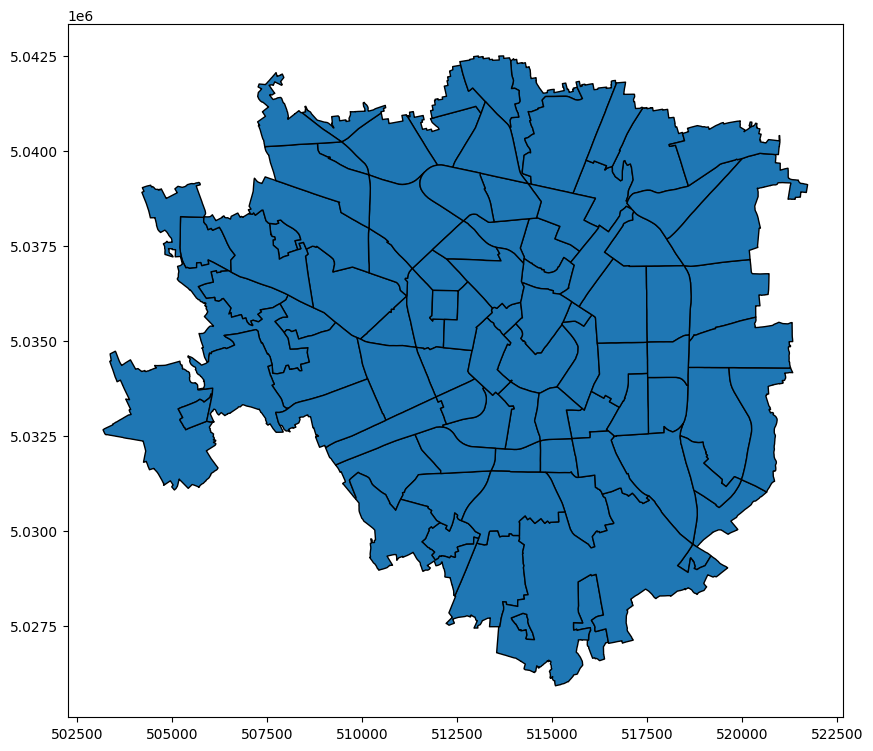

In [ ]:
import gdown
import geopandas as gpd

# Download NIL boundaries from Google Drive
gdown.download("https://drive.google.com/uc?id=1QZLg2b9OGUsi6rv4kFZlGgFxCut3nCGz", "ds964_nil_wm.geojson", quiet=False)

# Load and reproject to EPSG:32632
nil_gdf = gpd.read_file("ds964_nil_wm.geojson").to_crs(epsg=32632)

nil_gdf.plot(edgecolor='black', figsize=(10, 10))
nil_gdf.head()


Cells without NIL assigned (NaN): 37


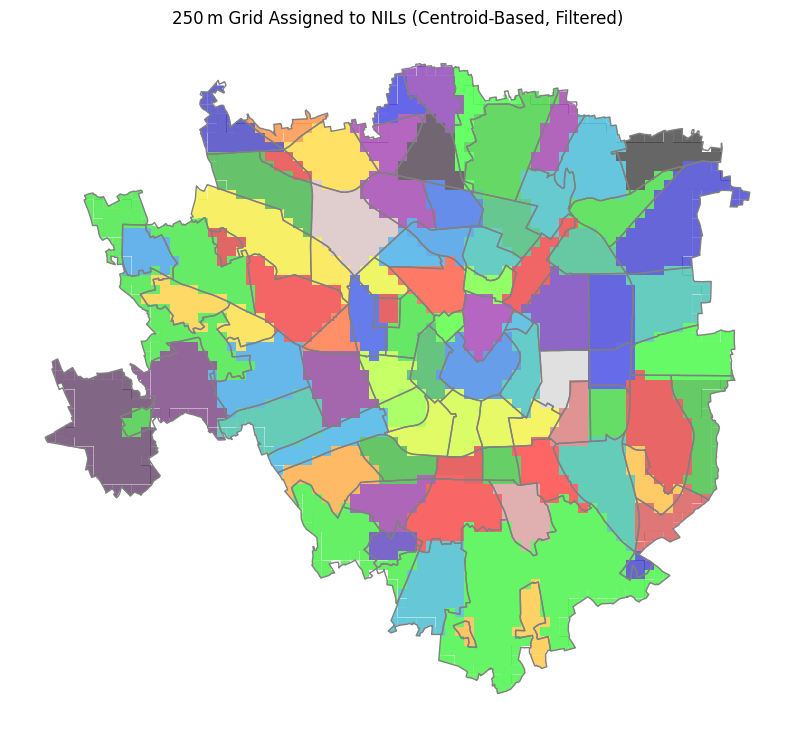

Total number of cells after filtering: 3105
Average number of cells per NIL: 35.28


In [ ]:
import numpy as np
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

# Load Milan and NIL boundaries in EPSG:32632
nil_gdf = gpd.read_file("ds964_nil_wm.geojson").to_crs(epsg=32632)

# Grid parameters
cell_size = 250  # meters
xmin, ymin, xmax, ymax = milano.total_bounds
cols = np.arange(xmin, xmax, cell_size)
rows = np.arange(ymin, ymax, cell_size)

# Generate regular grid cells
polygons = [box(x, y, x + cell_size, y + cell_size) for x in cols for y in rows]
grid = gpd.GeoDataFrame({'geometry': polygons}, crs=milano.crs)

# Clip to Milan boundary
grid = gpd.overlay(grid, milano, how='intersection')
grid['grid_id'] = range(len(grid))

# Assign NIL via centroid spatial join
centroids = grid.copy()
centroids['geometry'] = centroids.centroid
centroids_with_nil = gpd.sjoin(centroids, nil_gdf, how='left', predicate='within')

grid['NIL'] = centroids_with_nil['NIL'].values
grid['ID_NIL'] = centroids_with_nil['ID_NIL'].values

# Drop cells without NIL assignment
n_missing = grid['NIL'].isna().sum()
print(f"Cells without NIL assigned (NaN): {n_missing}")
grid = grid.dropna(subset=["NIL"])

# Export cleaned grid
grid[['grid_id', 'geometry', 'NIL', 'ID_NIL']].to_file("grid_250m_with_nil_clean.geojson", driver="GeoJSON")

# Plot grid and NIL overlay
fig, ax = plt.subplots(figsize=(10, 10))
nil_gdf.boundary.plot(ax=ax, edgecolor="gray", linewidth=1)
grid.plot(ax=ax, column='NIL', cmap='nipy_spectral', legend=False, alpha=0.6)
plt.title("250 m Grid Assigned to NILs (Centroid-Based, Filtered)")
plt.axis("off")
plt.show()

# Grid summary stats
print(f"Total number of cells after filtering: {len(grid)}")
mean_cells_per_nil = grid.groupby("NIL").size().mean()
print(f"Average number of cells per NIL: {mean_cells_per_nil:.2f}")


In [ ]:
# Total number of grid cells
n_cells = len(grid)
print(f"Total number of grid cells: {n_cells}")

# Cells per NIL and average
cells_per_nil = grid.groupby("NIL").size()
mean_cells_per_nil = cells_per_nil.mean()
print(f"Average number of cells per NIL: {mean_cells_per_nil:.2f}")


Total number of grid cells: 3105
Average number of cells per NIL: 35.28


In [ ]:
# Count distinct NILs in the grid
n_distinct_nils = grid['NIL'].nunique()
print(f"Number of distinct NILs in the grid: {n_distinct_nils}")


Number of distinct NILs in the grid: 88


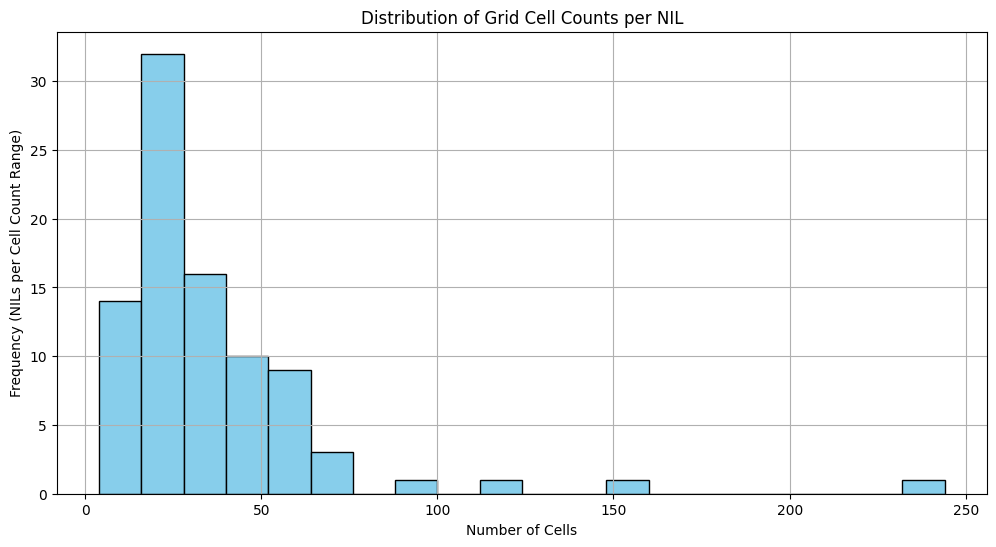

In [ ]:
import matplotlib.pyplot as plt

# Histogram of cell counts per NIL
cells_per_nil = grid.groupby("NIL").size()

plt.figure(figsize=(12, 6))
plt.hist(cells_per_nil, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Grid Cell Counts per NIL")
plt.xlabel("Number of Cells")
plt.ylabel("Frequency (NILs per Cell Count Range)")
plt.grid(True)
plt.show()
